In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import random as r
import pandas as pd

In [2]:
# Load the Excel file
file_path = './Example_Data_TE11764.xlsx'
excel_data = pd.ExcelFile(file_path)

# Load the "Prod. Steam Flow" sheet
steam_flow_data = pd.read_excel(file_path, sheet_name='Prod. Steam Flow')

# Remove the first two rows (headers) and any irrelevant columns
steam_flow_cleaned = steam_flow_data.iloc[2:, 1:].copy()

# Reset column headers
steam_flow_cleaned.columns = ['Date', 'Well 0', 'Well 1', 'Well 2', 'Well 3', 'Well 4']

# Reset the index
steam_flow_cleaned.reset_index(drop=True, inplace=True)

# Display the cleaned data
print(steam_flow_cleaned)


                   Date Well 0 Well 1 Well 2 Well 3 Well 4
0   2017-01-01 00:00:00      0      0      0      0      0
1   2017-01-02 00:00:00      0      0      0      0      0
2   2017-01-04 00:00:00      0      0      0      0      0
3   2017-01-08 00:00:00      0      0      0      0      0
4   2017-01-16 00:00:00      0      0      0      0      0
5   2017-01-31 00:00:00      0      0      0      0      0
6   2017-03-02 00:00:00      0      0      0      0      0
7   2017-04-02 00:00:00      0      0      0      0      0
8   2017-05-02 00:00:00      0      0      0      0      0
9   2017-06-02 00:00:00      0      0      0      0      0
10  2017-07-02 00:00:00      0      0      0      0      0
11  2017-08-01 00:00:00      0      0      0      0      0
12  2017-09-01 00:00:00      0      0      0      0      0
13  2017-10-01 00:00:00      0      0      0      0      0
14  2017-11-01 00:00:00      0      0      0      0      0
15  2017-12-01 00:00:00      0      0      0      0     

In [36]:
df = pd.DataFrame(steam_flow_cleaned)

Months = np.arange(0,41)
Well_0 = df['Well 0'].values
Well_1 = df['Well 1'].values
Well_2 = df['Well 2'].values
Well_3 = df['Well 3'].values
Well_4 = df['Well 4'].values
print(Well_0)

wells_combined = pd.DataFrame({
    0: Well_0,
    1: Well_1,
    2: Well_2,
    3: Well_3,
    4: Well_4
})

training_indices_0 = np.concatenate((np.arange(0,17), np.array([22,30])))
training_indices_1 = np.concatenate((np.arange(0,17), np.array([27])))
training_indices_2 = np.concatenate((np.arange(0,19), np.array([25])))
training_indices_3 = np.concatenate((np.arange(0,21), np.array([32])))
training_indices_4 = np.concatenate((np.arange(0,27), np.array([29])))

total_steam_flow = Well_0 + Well_1 + Well_2 + Well_3 + Well_4

print(wells_combined.shape)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 10.9 22.12 21.73 21.43 21.19 21 20.92
 20.91 20.94 20.92 20.53 20.18 20.19 20.34 20.59 20.96 21.5 22.28 23.4
 25.02 27.15 29.96 30.84]
(41, 5)


In [37]:
def GPR_Model(Months, target_well_index, steam_flows, total_steam, TI_target_well, LS_bounds=(1e-1, 10), nu=1.5, alpha=1e-10):
    
    y_target_well = steam_flows[target_well_index].values
    X_train, y_train = Months[TI_target_well], y_target_well[TI_target_well]
    
    kernel = 1 * Matern(length_scale_bounds=LS_bounds, nu=nu)
    
    other_well_sums = total_steam - steam_flows[target_well_index].values
    
    # For the remaining sum cases
    X_OW = []
    y_OW = []
    for i in range(len(Months)):
        if other_well_sums[i] == 0:
            X_OW.append(i)
            y_OW.append(0)
        if i in TI_target_well:
            X_OW.append(i)
            y_OW.append(total_steam[i]-y_target_well[i])
            
    # For the target well case
    X_add = []
    y_add = []
    for i in range(len(Months)):
        if other_well_sums[i]==0:
            X_add.append(i)
            y_add.append(total_steam[i]-other_well_sums[i])
            
    X_OW = np.array(X_OW)
    y_OW = np.array(y_OW)
    
    X_add = np.array(X_add).reshape(-1,1)
    y_add = np.array(y_add)
    
    X_train = np.concatenate([X_train.reshape(-1, 1), X_add])
    y_train = np.concatenate([y_train, y_add])
            
    GP_target = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=alpha)
    GP_other_wells = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=alpha)

    # Fit the Gaussian Process model
    GP_target.fit(X_train.reshape(-1,1), y_train)
    GP_other_wells.fit(X_OW.reshape(-1,1), y_OW)

    # Make predictions
    MP_target, SP_target = GP_target.predict(Months.reshape(-1, 1), return_std=True)
    MP_other_wells, SP_other_wells = GP_other_wells.predict(Months.reshape(-1, 1), return_std=True)

    return MP_target, SP_target, MP_other_wells, SP_other_wells


In [38]:
MT, ST, MOW, SOW = GPR_Model(Months, 0, wells_combined, total_steam_flow, training_indices_0)
difference = total_steam_flow - MT - MOW
MT = MT+(difference/2)
MT = np.array(MT, dtype=np.float64)

MOW = MOW+(difference/2)
MOW = np.array(MOW, dtype=np.float64)

C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\_gpr.py:506: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "
C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\_gpr.py:506: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _c

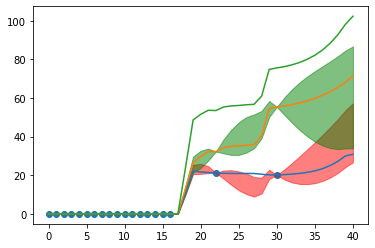

In [40]:
plt.plot(Months, wells_combined[0].values)
plt.plot(Months, total_steam_flow-Well_0)
plt.plot(Months, total_steam_flow)
plt.scatter(Months[training_indices_0], wells_combined[0].values[training_indices_0])
# plt.plot(Months, M)
plt.fill_between(Months.flatten(), MT - 1.96*ST, MT + 1.96*ST, color='red', alpha=0.5, label='Well 3 Uncertainty')
plt.fill_between(Months.flatten(), MOW - 1.96*SOW, MOW + 1.96*SOW, color='green', alpha=0.5, label='Well 3 Uncertainty')